In [1]:
import os,sys
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
import h5py
sys.path.append('../../code/misc')
#import webplotdigitizer as wpd
from scipy.special import erf

%matplotlib inline
%load_ext autoreload
%autoreload 2
 
from scipy.stats import chi2 as chi2_scipy
from scipy.optimize import dual_annealing
from scipy.optimize import minimize

import matplotlib.pyplot as plt
from matplotlib import rc
from matplotlib import rcParams

from scipy.special import factorial

In [2]:
def loadFile(fileString):
    in_file = str(fileString)
    with h5py.File(in_file, 'r') as h5f:
        # Read each dataset back into memory
        counts = h5f['counts'][:]
        det_res = h5f['det_res'][:]
        exp = h5f['exp'][()]
        cin_min = h5f['cin_min'][:]
        cin_max = h5f['cin_max'][:]
        cout_min = h5f['cout_min'][:]
        cout_max = h5f['cout_max'][:]
        flux = h5f['flux'][:]

    E_mean = np.mean([cout_min, cout_max], axis = 0)
    dE = cout_max - cout_min
    
#    flux = counts/exp/dE
    
    return counts, det_res, exp, cin_min, cin_max, E_mean, dE, flux, cout_max, cout_min

In [3]:
## Define the functions we will use
from scipy.special import gammaln

class poisson:
    """ A set offunctions for calculation the chisq associated with different hypotheses
    """
    def __init__(self,ens,dat,null_mod,sig_template, Exp, DE, centerE):
        self._ens = ens
        self._dat = dat
        self._null_mod = null_mod
        self._sig_template = sig_template
        self._A_sig = 0.0
        self._Exp = Exp
        self._DE = DE
        self.centerE = centerE

    #Basic poisson function. Tests the hypothesis.
    def poisson(self,x): 
        null_mod = self._null_mod(self._ens,x[1:], self._Exp, self._DE, self.centerE)
        sig_mod = self._sig_template*x[0] 
        
        k = self._dat 
        λ = null_mod + sig_mod 

        if np.any(λ <= 0):
            return np.inf
        
        logPoisson = k * np.log(λ) - λ - gammaln(k + 1) 
        
        return -2 * np.sum(logPoisson)

    
    #Similar to poisson, but with no sig_mod; this test only evaluates the null case
    def poissonNull(self,x): 
        null_mod = self._null_mod(self._ens,x, self._Exp, self._DE, self.centerE)
        
        k = self._dat 
        λ = null_mod 
        
        if np.any(λ <= 0):
            return np.inf
            
        logPoisson = k * np.log(λ) - λ - gammaln(k + 1) 
        
        return -2 * np.sum(logPoisson)

    
    #Same as poisson, but with adjusted definitions for the null_mod and sig_mod variables
    def poissonFixedSignal(self,x):
        null_mod = self._null_mod(self._ens,x, self._Exp, self._DE, self.centerE) #,self.centerE)
        sig_mod = self._sig_template*self._A_sig

        k = self._dat 
        λ = null_mod + sig_mod

        if np.any(λ <= 0):
            return np.inf
        
        logPoisson = k * np.log(λ) - λ - gammaln(k + 1) 

        return -2 * np.sum(logPoisson)
    
    def fix_signal_strength(self,A_sig):
        self._A_sig = A_sig
        
def old_mod_poly(ens,x):
    """ A simple polynomial model for the background
    """
    A, B, C = x
    return A+B*ens + C*ens**2

def mod_poly(ens, x, Exp, DE, eVal):
    """ A simple polynomial model for the background
    """
    A, B, C = x
    return A + B*(ens - eVal) + C*(ens - eVal)**2

def mod_power_law(ens, x, Exp, DE, eVal):
    logA, B = x
    return (np.exp(logA)*(ens/eVal)**B) * (Exp * DE)

In [4]:
def return_sin_theta_lim(E_line,flux,D_factor):
    """
    D_factor [keV/cm^2] 
    flux [cts/cm^2/s/sr]
    E_line [keV] (dark matter mass is twice this value)
    returns: associated sin^2(2theta)
    """
    DMmass = 2.*E_line
    res = (4.*np.pi*DMmass/D_factor)/1.361e-22*(1/DMmass)**5*flux
    return res

def quadratic(E, a, b, c):
    return a*E**2 + b*E + c
    
def Gaussian_Line(E_min, E_max, E_cent, Amp, std):
    return Amp*(erf((E_cent - E_min)/(np.sqrt(2)*std)) - erf((E_cent - E_max)/(np.sqrt(2)*std)))/2.

def powerLaw(E, a, b):
    return a*(E**b)

In [5]:
def runPipeline(counts, det_res, exp, cin_min, cin_max, E_mean, dE, lineVal, window):
    
    Input_Bkg = powerLaw(E_mean, 0.004, 0.5) # cts/cm^2/s/keV
    Input_Sig = Gaussian_Line(cin_min, cin_max, lineVal, 1.0, 0.005)
    Input_Model = Input_Bkg + Input_Sig
    
    OutputBackground = np.matmul(det_res, Input_Bkg)
    OutputSignal = np.matmul(det_res, Input_Sig)
    Output_Model = np.matmul(det_res, Input_Model)

    whs_reduced = np.where((E_mean >= lineVal-window) & (E_mean <= lineVal+window))[0]
    E_mean_reduced = E_mean[whs_reduced]
    counts_reduced = counts[whs_reduced]
    Output_Model_reduced = Output_Model[whs_reduced]
    OutputSignal_reduced = OutputSignal[whs_reduced]
    dE_reduced = dE[whs_reduced]
    
    #Best fit with just background
    poisson_instance = poisson(E_mean_reduced,counts_reduced,mod_power_law,(OutputSignal_reduced * exp), exp, dE_reduced, lineVal)
    mn_null = minimize(poisson_instance.poissonNull,np.array([np.log(0.3),0.01]),method='L-BFGS-B')

    backgroundParams = mn_null.x

    
    #Best fit with signal and background
    mn = minimize(poisson_instance.poisson,np.array([(1.e-2),mn_null.x[0],mn_null.x[1]]),method='L-BFGS-B')
    signalParams = mn.x
        
    #Alright, now for the meat of it. We need to compute the profile likelihood
    A_sig_array = np.linspace(0,20,100)

    bfList = []

    poisson_sig_array = np.zeros(len(A_sig_array))
    bf = mn.x[1:]
    
    #Iterate over every the signal array
    for i in range(len(A_sig_array)):
        poisson_instance.fix_signal_strength(A_sig_array[i])
        #mn_profile = minimize(poisson_instance.poissonFixedSignal,bf,method='L-BFGS-B',
        #                  options={'fatol':1e-10,'xatol':1e-10,'adaptive':True})

        mn_profile = minimize(poisson_instance.poissonFixedSignal,bf,method='L-BFGS-B', 
                            bounds=[(-5, 10),(-5, 5)], options={'ftol': 1e-12,'gtol': 1e-8,'maxiter': 1000, 'maxls': 50})
        
        bf = mn_profile.x
        poisson_sig_array[i] = mn_profile.fun
        bfList.append(bf)
    
    bestFit = np.min(poisson_sig_array)
    bestFitIndex = np.argmin(poisson_sig_array)
    testStat = poisson_sig_array-bestFit

    bestProfileSignal = [A_sig_array[bestFitIndex], bfList[bestFitIndex][0], bfList[bestFitIndex][1]]

    amin = np.argmin((testStat - 2.71)**2) #2.71 comes from Wilk's Theorem, if memory serves
    limit_signal_strength = A_sig_array[amin]

    ReducedVals = [whs_reduced,E_mean_reduced,counts_reduced, OutputBackground[whs_reduced], OutputSignal[whs_reduced], dE_reduced]

    return backgroundParams, signalParams, bestProfileSignal, bestFit, bfList, A_sig_array, testStat, limit_signal_strength, ReducedVals

In [6]:
def relevantPlots(E_mean, counts, backgroundParams, signalParams, profileSignal, bfList, A_sig_array, testStat, limit_signal_strength, reducedVals, lineVal, Exp):
    #Unpack reduced variables
    whsReduced = reducedVals[0]
    EMeanReduced = reducedVals[1]
    counts_reduced = reducedVals[2]
    output_background_reduced = reducedVals[3]
    output_signal_reduced = reducedVals[4]
    dE_reduced = reducedVals[5]

    #Assign all of our variables for subsequent graphing
    signal_template = output_signal_reduced * Exp
    background_only = mod_power_law(EMeanReduced, backgroundParams, Exp, dE_reduced, lineVal)
    best_signal = signalParams[0] * signal_template
    best_background = mod_power_law(EMeanReduced, signalParams[1:], Exp, dE_reduced, lineVal)
    best_model = best_background + best_signal

    #Now consulting variables from the profile likelihood
    best_index = np.argmin(testStat)
    best_profile_background = mod_power_law(EMeanReduced,bfList[best_index], Exp, dE_reduced, lineVal)
    best_profile_signal = (A_sig_array[best_index] * signal_template)
    best_profile_model = (best_profile_background + best_profile_signal)
    target = np.min(testStat) + 2.71
    closestIndex = np.argmin(np.abs(testStat - target))
    limit_background = mod_power_law(EMeanReduced, bfList[closestIndex], Exp, dE_reduced, lineVal)
    limit_signal = (A_sig_array[closestIndex] * signal_template)
    limit_model = limit_background + limit_signal
    residuals = counts_reduced - best_model
    
    #Begin actually graphing
    fig, ax = plt.subplots(2, 3,figsize=(14, 8))

    #Background only
    ax[0,0].step(EMeanReduced,counts_reduced,where='mid',color='black',label='Data')
    ax[0,0].plot(EMeanReduced, background_only, color='tab:orange', label='Background-only fit')
   
    ax[0,0].set_title("Data vs Background-only Model")
    ax[0,0].set_xlabel("Energy [keV]")
    ax[0,0].set_ylabel("Counts")
    ax[0,0].legend()

    #Best fit
    ax[1,0].step(EMeanReduced, counts_reduced, where='mid', color='black', label='Data')
    ax[1,0].plot(EMeanReduced, best_background, color='tab:blue', label='Background')
    ax[1,0].plot(EMeanReduced, best_signal, color='tab:red', linestyle='--', label='Signal')

    ax[1,0].plot(EMeanReduced,best_model,color='tab:orange',linewidth=2,label='Total model')
    ax[1,0].set_title("Best-fit Signal + Background From Regular Model")
    ax[1,0].set_xlabel("Energy [keV]")
    ax[1,0].set_ylabel("Counts")
    ax[1,0].legend()

    #Profile likelihood
    ax[0,1].plot(A_sig_array, testStat, color='black')
    ax[0,1].axhline(np.min(testStat) + 2.71, color='red', linestyle=':', label='Test Statistic')
    ax[0,1].set_title("Profile Likelihood")
    ax[0,1].set_xlabel(r"Line Flux")
    ax[0,1].set_ylabel("Test Statistic")

    #Profile best fit
    ax[0,2].step(EMeanReduced, counts_reduced, where='mid', color='black', label='Data')
    ax[0,2].plot(EMeanReduced, best_background, color='tab:blue', label='Background')
    ax[0,2].plot(EMeanReduced, best_signal, color='tab:red', linestyle='--', label='Signal')

    ax[0,2].plot(EMeanReduced,best_model,color='tab:orange',linewidth=2,label='Total model')
    ax[0,2].set_title("Best-fit Signal + Background From Profile Likelihood")
    ax[0,2].set_xlabel("Energy [keV]")
    ax[0,2].set_ylabel("Counts")
    ax[0,2].legend()
    
    #Upper-limit
    ax[1,2].step(EMeanReduced, counts_reduced, where='mid', color='black', label='Data')
    ax[1,2].plot(EMeanReduced, limit_background, color='tab:blue', label='Background')
    ax[1,2].plot(EMeanReduced, limit_signal, color='tab:red', linestyle='--', label='Signal at limit' )
    ax[1,2].plot(EMeanReduced, limit_model, color='tab:orange', linewidth=2, label='Total model')

    ax[1,2].set_title(f"Model at Upper Limit = {limit_signal_strength:.3g}")
    ax[1,2].set_xlabel("Energy [keV]")
    ax[1,2].set_ylabel("Counts")
    ax[1,2].legend()

    #Residuals
    ax[1,1].axhline(0, color='black', linestyle='--')
    ax[1,1].step(EMeanReduced, residuals, where='mid', color='black')
    
    ax[1,1].set_title("Best-Fit Model Residuals")
    ax[1,1].set_xlabel("Energy [keV]")
    ax[1,1].set_ylabel("Residual [counts]")

    #And done! Now we just do some final formatting
    plt.tight_layout()
    plt.show()

    return fig, ax


# For a File Beginning In 1

In [7]:
# Counts, Det_res, Exp, Cin_min, Cin_max, EMean, dE, Flux, cout_max, cout_min = loadFile('fileStorage1/101001010/outputFile.h5')

In [8]:
# backgroundParams, signalParams, profileSignal, bfList, A_sig_array, testStat, limit_signal_strength, reducedVals = runPipeline(Counts, Det_res, Exp, Cin_min, Cin_max, EMean, dE, 6.580, 0.25)
# fig, axes = relevantPlots(EMean, Counts, backgroundParams, signalParams, profileSignal, bfList, A_sig_array, testStat, limit_signal_strength, reducedVals, 6.580)

# For a File Beginning In 0

In [9]:
# Counts, Det_res, Exp, Cin_min, Cin_max, EMean, dE, Flux, cout_max, cout_min = loadFile('fileStorage0/000100000/outputFile.h5')
# backgroundParams, signalParams, bfList, A_sig_array, testStat, limit_signal_strength, reducedVals = runPipeline(Counts, Det_res, Exp, Cin_min, Cin_max, EMean, dE, 6.580, 0.25)
# fig, axes = relevantPlots(EMean, Counts, backgroundParams, signalParams, bfList, A_sig_array, testStat, limit_signal_strength, reducedVals, 6.58)

# For a file beginning in 2

In [10]:
# Counts, Det_res, Exp, Cin_min, Cin_max, EMean, dE, Flux, cout_max, cout_min = loadFile('fileStorage2/201000010/outputFile.h5')
# backgroundParams, signalParams, bfList, A_sig_array, testStat, limit_signal_strength, reducedVals = runPipeline(Counts, Det_res, Exp, Cin_min, Cin_max, EMean, dE, 6.580, 0.25)
# fig, axes = relevantPlots(EMean, Counts, backgroundParams, signalParams, bfList, A_sig_array, testStat, limit_signal_strength, reducedVals, 6.58)

# For a file beginning in 3

In [11]:
# Counts, Det_res, Exp, Cin_min, Cin_max, EMean, dE, Flux, cout_max, cout_min = loadFile('fileStorage3/300000010/outputFile.h5')
# backgroundParams, signalParams, bfList, A_sig_array, testStat, limit_signal_strength, reducedVals = runPipeline(Counts, Det_res, Exp, Cin_min, Cin_max, EMean, dE, 6.580, 0.025)
# fig, axes = relevantPlots(EMean, Counts, backgroundParams, signalParams, bfList, A_sig_array, testStat, limit_signal_strength, reducedVals, 6.58)

# For a file beginning in 9

In [12]:
# Counts, Det_res, Exp, Cin_min, Cin_max, EMean, dE, Flux, cout_max, cout_min = loadFile('fileStorage9/900002010/outputFile.h5')
# backgroundParams, signalParams, bfList, A_sig_array, testStat, limit_signal_strength, reducedVals = runPipeline(Counts, Det_res, Exp, Cin_min, Cin_max, EMean, dE, 6.580, 0.25)
# fig, axes = relevantPlots(EMean, Counts, backgroundParams, signalParams, bfList, A_sig_array, testStat, limit_signal_strength, reducedVals, 6.58)

# For a File That Actually Has the Iron Line

In [7]:
Counts, Det_res, Exp, Cin_min, Cin_max, EMean, dE, Flux, cout_max, cout_min = loadFile('ironDirectory/300003010/outputFile.h5')

In [8]:
backgroundParams, signalParams, profileSignal, bestFitTestStat, bfList, A_sig_array, testStat, limit_signal_strength, reducedVals = runPipeline(Counts, Det_res, Exp, Cin_min, Cin_max, EMean, dE, 6.49, 0.025)
print(f"Best fit signal amplitude: {profileSignal[0]} \nBest fit background logA: {profileSignal[1]} \nBest fit background power law slope: {profileSignal[2]} \nBest Fit Test Statistic: {bestFitTestStat}")

Best fit signal amplitude: 0.20202020202020202 
Best fit background logA: 2.189283199438569 
Best fit background power law slope: -5.0 
Best Fit Test Statistic: 4626.47474358271


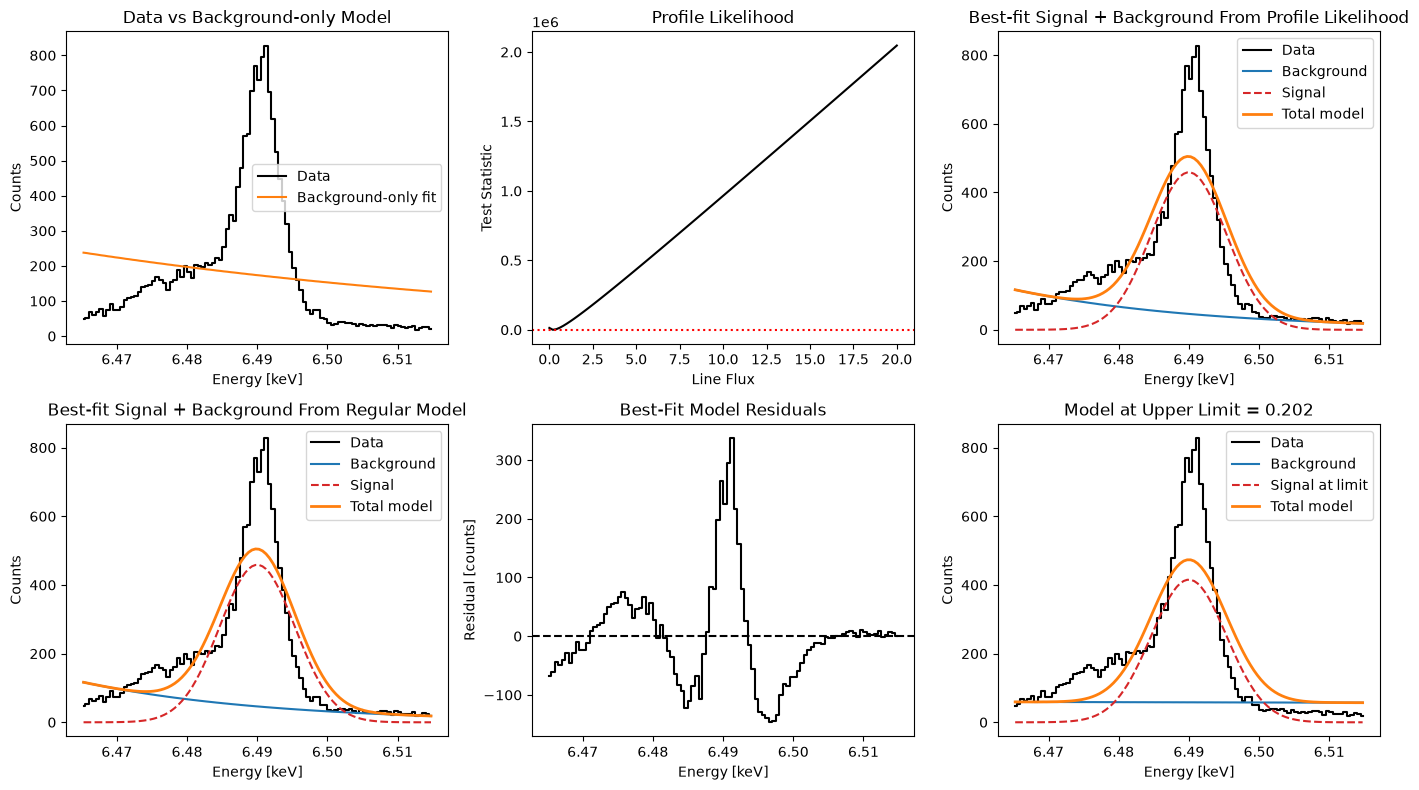

In [9]:
fig, axes = relevantPlots(EMean, Counts, backgroundParams, signalParams, profileSignal, bfList, A_sig_array, testStat, limit_signal_strength, reducedVals, 6.49, Exp)

# Searching the Data for the Iron Line

The ultimate goal here is to look through the data and find a line signature without having to know it going in. To test our ability to do this, let's search for lines in this data.

In [ ]:
lineVals = np.linspace()

for lineVal in lineVals:
    backgroundParams, signalParams, profileSignal, bestFitTestStat, bfList, A_sig_array, testStat, limit_signal_strength, reducedVals = runPipeline(Counts, Det_res, Exp, Cin_min, Cin_max, EMean, dE, lineVal, 0.025)
    